# Week 8 Project Task - DMNN
## Convolutional Neural Networks: From Architecture to Interpretation


## Imports and Setup

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Task 1 - Reconnect to the Data (Understanding Input Structure)

## Dataset Selection: Fashion MNIST

**Why Fashion MNIST?**

Fashion MNIST is a dataset of Zalando's article images consisting of 70,000 grayscale images (28×28 pixels) across 10 clothing categories. It is more challenging than standard MNIST digits while remaining computationally manageable, making it ideal for demonstrating CNN concepts without requiring heavy compute.

The 10 classes are: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot.

### 1.1 Load and Inspect the Data

In [18]:
# Loading Fashion MNIST
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Printting input shape and dataset sizes
print("Training set shape:", X_train_full.shape)
print("Test set shape:", X_test.shape)
print("Single image shape:", X_train_full[0].shape)
print("Number of classes:", len(class_names))
print("Pixel value range:", X_train_full.min(), "-", X_train_full.max())

Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Single image shape: (28, 28)
Number of classes: 10
Pixel value range: 0 - 255


### 1.2 Class Distribution

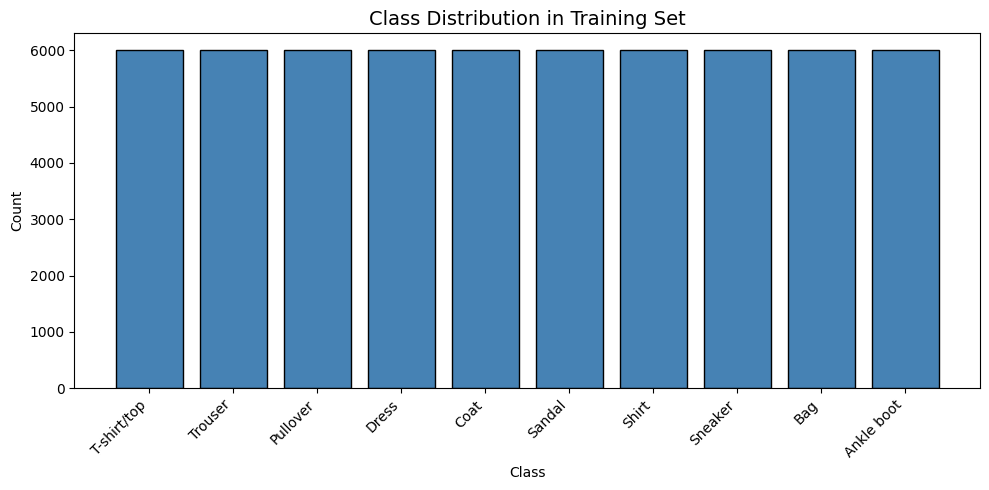

T-shirt/top: 6000 samples
Trouser: 6000 samples
Pullover: 6000 samples
Dress: 6000 samples
Coat: 6000 samples
Sandal: 6000 samples
Shirt: 6000 samples
Sneaker: 6000 samples
Bag: 6000 samples
Ankle boot: 6000 samples


In [ ]:
# Class distribution
unique, counts = np.unique(y_train_full, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in unique], counts, color='steelblue', edgecolor='black')
plt.title('Class Distribution in Training Set', fontsize=14)
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Printting exact counts
for i, name in enumerate(class_names):
    print(f"{name}: {counts[i]} samples")

### 1.3 One Example Per Class

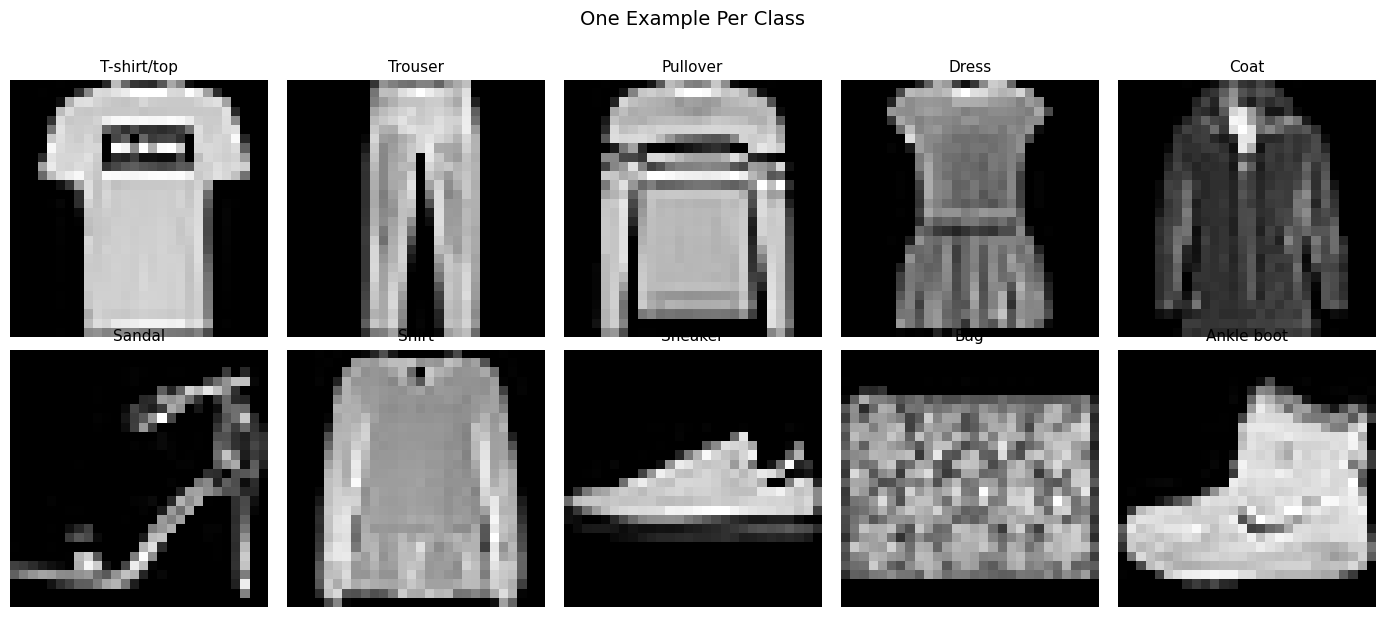

In [ ]:
# Visualising one example per class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(10):
    idx = np.where(y_train_full == i)[0][0]
    axes[i].imshow(X_train_full[idx], cmap='gray')
    axes[i].set_title(class_names[i], fontsize=11)
    axes[i].axis('off')

plt.suptitle('One Example Per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.4 Written Explanation

All images within the Fashion MNIST training set are 28 × 28 pixel grayscale photographs, each holding an integer intensity value between 0 and 255, representing a specific type of clothing (shirt, pants, etc.) photographed from a single viewpoint. There are 60,000 training images and 10,000 test images in the dataset with equal distribution among the ten categories and 6,000 images per category; hence, the categories have a balanced number of images (i.e., no need to address issues of class imbalance).

The spatial organization of pixels plays a critical role for this dataset. Any clothing image consists of neighboring pixels forming meaningful visual patterns (the outline of a shirt sleeve, the curvature of a shoe sole, etc.), which together represent the shapes and textures that distinguish one category of garments from another. Shuffling the pixel locations randomly will turn an image into nothing but random noise while retaining the exact same pixel values. Therefore, it is not merely the pixel values themselves that carry the relevant discriminative information, but rather how the pixels are arranged.

Using a fully-connected (dense) neural network would be an extremely inefficient method for processing this data. Flattening a 28 × 28 image results in a 1-D vector of length 784. Therefore, connecting all 784 possible input values to a relatively modest-sized hidden layer with 128 neurons would result in more than 100,000 parameters in that layer alone, and the network would not treat any two pixels as related in any way. In particular, the network would ignore the fact that many pixels on a given image are close to one another in the 2-D space. In contrast, a Convolutional Neural Network (CNN), utilizes small local filters that slide over the entire image, using the same filter weights at every location. As a result, a CNN is able to reduce the total number of parameters greatly, while also providing a mechanism to preserve and utilize the spatial relationships among pixels, which are the most important for classification.


# Task 2 – Build a Baseline CNN (Minimal Architecture)

### 2.1 Data Preprocessing

In [ ]:
# Normalising pixel values to [0, 1]
X_train_full_norm = X_train_full.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Reshaping to add channel dimension: (samples, 28, 28, 1)
X_train_full_norm = X_train_full_norm.reshape(-1, 28, 28, 1)
X_test_norm = X_test_norm.reshape(-1, 28, 28, 1)

# Splitting training data into train and validation sets (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full_norm, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test_norm.shape)

Training set: (48000, 28, 28, 1)
Validation set: (12000, 28, 28, 1)
Test set: (10000, 28, 28, 1)


### 2.2 Baseline CNN Architecture

In [20]:
# Baseline CNN: 1 Conv layer -> 1 Pooling layer -> 1 FC output layer
baseline_model = models.Sequential([
    # Convolutional layer: 16 filters, 3x3 kernel, ReLU activation
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv_layer'),
    
    # Max pooling layer: 2x2 pool size
    layers.MaxPooling2D((2, 2), name='pool_layer'),
    
    # Flatten spatial dimensions to 1D
    layers.Flatten(name='flatten'),
    
    # Fully connected output layer: 10 classes with softmax
    layers.Dense(10, activation='softmax', name='output_layer')
], name='Baseline_CNN')

baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_layer (Conv2D)             │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_layer (MaxPooling2D)       │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        27,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,210 (106.29 KB)

 Trainable params: 27,210 (106.29 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3 Baseline Model Explanation

The baseline CNN has a total of 27,210 trainable parameters that are listed here.

The convolutional layer uses 16 filters that are 3 × 3 to apply to the single-channel input. Each filter has 3 × 3 × 1 = 9 weights and 1 bias parameter. There are 10 parameters for each filter and there are a total of 160 parameters for this layer. This layer changes the 28 × 28 × 1 input to a 26 × 26 × 16 feature map. The reason for this change is due to the fact that we have used no padding in the convolutional layer; therefore, the spatial dimensions of the input will reduce by 2 pixels in both x and y directions. In other words, each one of the 16 filters will be looking for a specific low level visual pattern (such as a horizontal edge, a vertical edge, a diagonal line, or a small curve) when they slide over the input. As each filter slides over the input, it creates a feature map that indicates the areas in which the specific low level visual pattern is located.

The MaxPooling2D layer with a window of 2 × 2 will then take half of the spatial dimension of the previous feature map (26 × 26) and create an additional feature map with spatial dimension of 13 × 13. It does this by selecting the maximum value at each 2 × 2 area of the original feature map. This operation accomplishes three things: 1) it adds some degree of translational invariance (i.e., if you shift your input slightly in either the x or y direction, the output will not change significantly); 2) it decreases the number of computations required for subsequent layers; and 3) it effectively increases the size of the receptive field of the network so that the layers after pooling can look for larger patterns in the input. As stated earlier, the MaxPooling2D layer has no trainable parameters.

Following the pooling layer, the flattened vector is created with a length of 13 × 13 × 16 = 2,704. The final layer is a fully connected layer that takes the entire 2,704 element vector and applies it to the 10 output neurons (one for each of the classes). Therefore, this layer is creating 2,704 × 10 + 10 = 27,050 parameters. For most shallow networks like the one described above, the majority of the network's parameters come from this layer as it represents the classification head.

### 2.4 Compile Baseline Model

In [7]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Baseline model compiled successfully.")

Baseline model compiled successfully.


# Task 3 – Architectural Extension (Design Reasoning)

## Design Change: Add a Second Convolutional Layer + Dropout

**What I changed:**
1. Added a **second Conv2D layer** with 32 filters after the first conv+pool block.
2. Added a **second MaxPooling2D** layer after the second conv layer.
3. Added **Dropout (0.25)** after flattening, before the output layer.

**Why I expect this to help:**
- The second convolutional layer allows the network to learn **higher-level features** (combinations of edges --> shapes like collars, soles, handles) by composing the low-level features from the first layer.
- Increasing filters from 16 to 32 gives the second layer more capacity to represent diverse patterns.
- Dropout regularises the model by randomly deactivating 25% of neurons during training, reducing co-adaptation and helping the model generalise better.

**One possible risk:**
- Adding more layers and filters **increases the number of parameters**, which raises the risk of **overfitting** especially if the dataset is small or training runs for too many epochs. The dropout partially mitigates this, but monitoring validation loss is essential.

### 3.1 Extended CNN Architecture

In [8]:
# Extended CNN: 2 Conv layers, 2 Pooling layers, Dropout, 1 FC output layer
extended_model = models.Sequential([
    # First conv block
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv_layer_1'),
    layers.MaxPooling2D((2, 2), name='pool_layer_1'),
    
    # Second conv block
    layers.Conv2D(32, (3, 3), activation='relu', name='conv_layer_2'),
    layers.MaxPooling2D((2, 2), name='pool_layer_2'),
    
    # Flatten + Dropout + Output
    layers.Flatten(name='flatten'),
    layers.Dropout(0.25, name='dropout'),
    layers.Dense(10, activation='softmax', name='output_layer')
], name='Extended_CNN')

extended_model.summary()

Model: "Extended_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_layer_1 (Conv2D)           │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_layer_1 (MaxPooling2D)     │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_layer_2 (MaxPooling2D)     │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,810 (50.04 KB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Extended Model Explanation

The extended CNN has 12,810 trainable parameters approximately 5,400 fewer than the baseline's 27,210. At first glance, this seems counterintuitive. However, this is due to the significant spatial dimension reduction. The first convolutional block (conv + pool), was the same for both models, producing a 13x13x16 feature map with 160 parameters. The second convolutional layer applied 32 filters of size 3×3 over the 16 input channels, which required (3x3x16 + 1) x 32 = 4,640 parameters, and reduced the spatial dimensions down to 11×11. The second pooling layer then halved this again, to 5×5, so the flattened vector was only 5x5x32 = 800 elements much less than the baseline's 2,704. Therefore, the final dense layer needed only 800×10 + 10 = 8,010 parameters. The dropout layer had zero trainable parameters; it would only randomly set 25% of the activations to 0 during the training process.

The critical point in the development of this new model is that while the addition of the second conv-pool block causes a significantly larger compression of the spatial dimensions before the activation reaches the dense layer, it does cause an increase in representational depth. In particular, the second convolutional layer can learn how to combine the low-level features learned by the first layer to produce higher-level features (such as collars, pockets, etc.) and even shoe shapes.

### 3.3 Compile Extended Model

In [9]:
extended_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Extended model compiled successfully.")

Extended model compiled successfully.


# Task 4 – Training Behaviour Analysis

### 4.1 Train Baseline CNN

In [ ]:
# Training baseline model
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8077 - loss: 0.5617 - val_accuracy: 0.8600 - val_loss: 0.4076
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8627 - loss: 0.3930 - val_accuracy: 0.8686 - val_loss: 0.3742
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8773 - loss: 0.3536 - val_accuracy: 0.8749 - val_loss: 0.3555
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8850 - loss: 0.3286 - val_accuracy: 0.8809 - val_loss: 0.3384
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8917 - loss: 0.3100 - val_accuracy: 0.8863 - val_loss: 0.3235
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8965 - loss: 0.2949 - val_accuracy: 0.8913 - val_loss: 0.3100
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9009 - loss: 0.2821 - val_accuracy: 0.8956 - val_loss: 0.3001
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9051 - loss: 0.2712 - val_accuracy: 0.

### 4.2 Train Extended CNN

In [ ]:
# Training extended model
extended_history = extended_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7623 - loss: 0.6619 - val_accuracy: 0.8391 - val_loss: 0.4495
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8380 - loss: 0.4487 - val_accuracy: 0.8626 - val_loss: 0.3872
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8545 - loss: 0.4057 - val_accuracy: 0.8745 - val_loss: 0.3549
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8642 - loss: 0.3811 - val_accuracy: 0.8822 - val_loss: 0.3360
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8689 - loss: 0.3648 - val_accuracy: 0.8832 - val_loss: 0.3296
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8759 - loss: 0.3480 - val_accuracy: 0.8875 - val_loss: 0.3192
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8787 - loss: 0.3390 - val_accuracy: 0.8923 - val_loss: 0.3057
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8817 - loss: 0.3263 - val_accuracy: 0.

### 4.3 Plot Training Curves

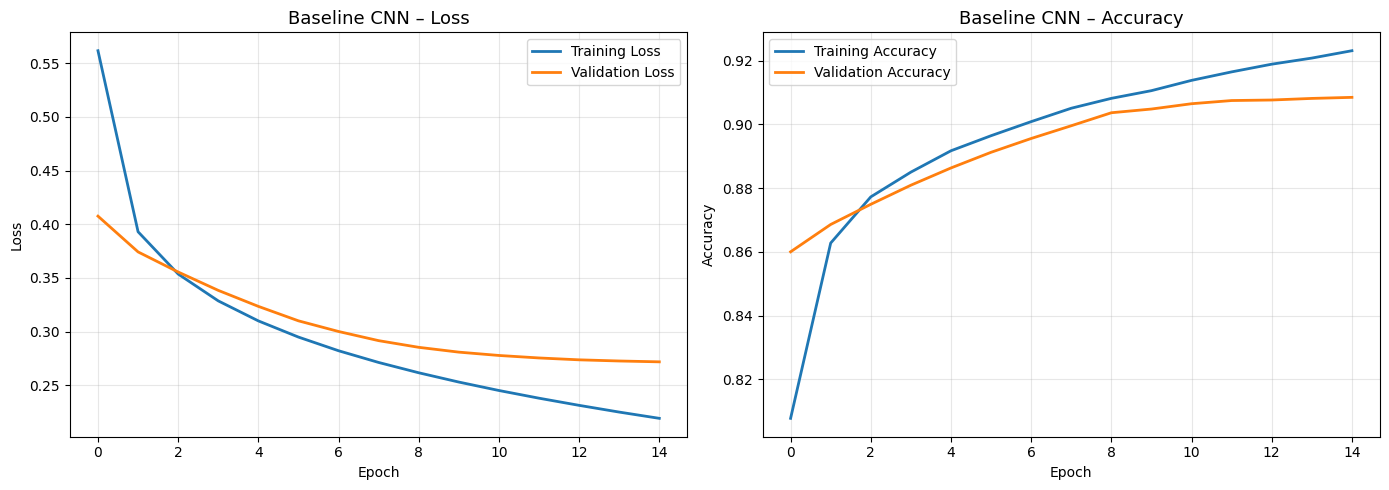

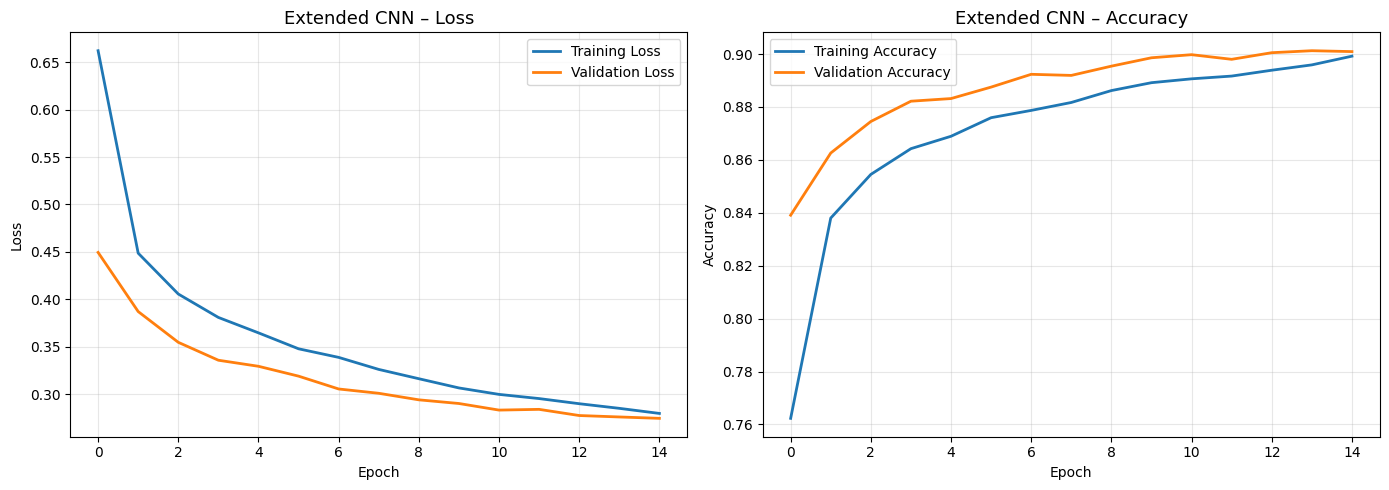

In [ ]:
def plot_training_curves(history, model_name):
    """Plot loss and accuracy curves for a model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title(f'{model_name} – Loss', fontsize=13)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy
    ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax2.set_title(f'{model_name} – Accuracy', fontsize=13)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plotting for both models
plot_training_curves(baseline_history, "Baseline CNN")
plot_training_curves(extended_history, "Extended CNN")

### 4.4 Side-by-Side Comparison

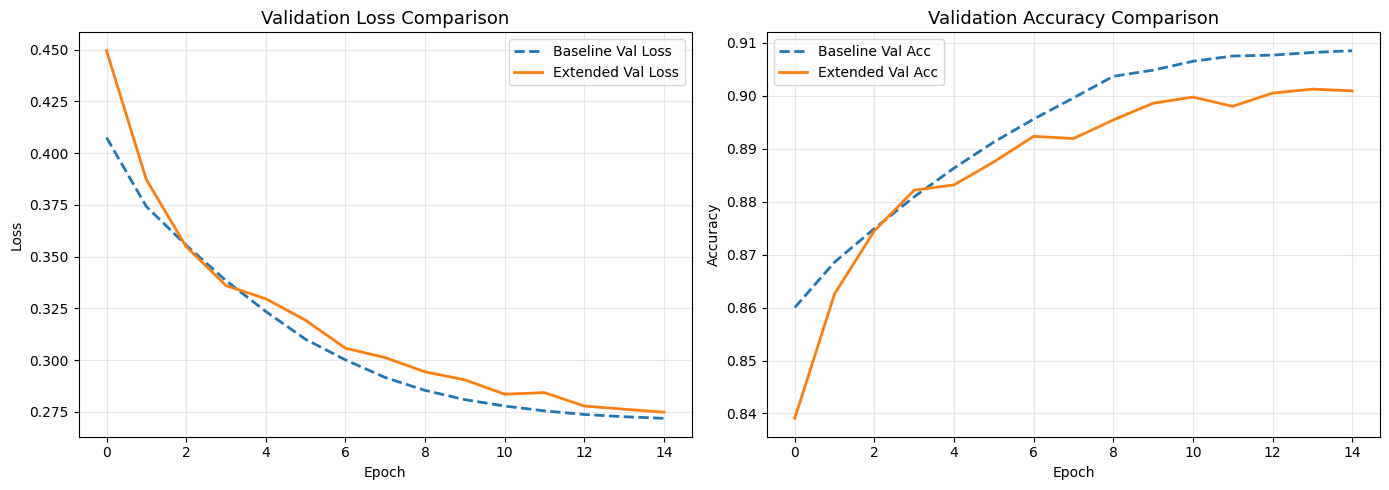

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(baseline_history.history['val_loss'], label='Baseline Val Loss', linewidth=2, linestyle='--')
axes[0].plot(extended_history.history['val_loss'], label='Extended Val Loss', linewidth=2)
axes[0].set_title('Validation Loss Comparison', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(baseline_history.history['val_accuracy'], label='Baseline Val Acc', linewidth=2, linestyle='--')
axes[1].plot(extended_history.history['val_accuracy'], label='Extended Val Acc', linewidth=2)
axes[1].set_title('Validation Accuracy Comparison', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 Training Behaviour Analysis

**Baseline CNN - Training Behavior:**

The baseline model converges progressively, with little or no fluctuation, through the entire 15 epochs. Loss for training data continues to decrease from an approximate value of 0.56 in epoch 1 to 0.22 in epoch 15. Accuracy for training data increases from approximately 81% to 92% across the same period. Loss for validation data likewise decreases from an approximate 0.41 in epoch 1 to 0.27 in epoch 15; however, accuracy for validation data increases from 86% to approximately 91% over the same time frame. From approximately epoch 6 onwards, the difference between training and validation metrics begins to increase and by epoch 15, training accuracy (approximately 92.3%) is higher than validation accuracy (approximately 90.9%), which results in a greater difference of approximately 1.4 percent, while training loss (approximately 0.22) is lower than validation loss (approximately 0.27). Although this represents a minor indication of overfitting, where the model is starting to fit training specific details, rather than developing generalized properties, the nature of the training curve itself is stable, with little fluctuation present.

**Extended CNN - Training Behavior:**

The extended model is initially slow to begin, with epoch 1 training accuracy approximately equal to 76%, versus 81% for the baseline model, and with an initial loss of 0.66 versus 0.56 for the baseline. It was anticipated that the extended model would begin training more slowly than the baseline model due to the presence of dropout which disrupts activation during early training, thus causing the network to develop more robust representations of input data rather than depending upon any one neuron path for processing the input data. The extended model's training accuracy reaches approximately 90% by epoch 15, and training loss falls to 0.28. The extended model's validation accuracy and loss follow a similar pattern to the training data, reaching approximately 90.1% accuracy, and 0.27 loss respectively. The extended model's training/val metric gap is considerably smaller than the baseline model approximately 1 percent difference in accuracy indicating that dropout has been effective in regularizing the extended model, thereby reducing overfitting. Both training and validation curves for the extended model are similarly smooth and stable throughout.

**Comparison:**

A comparison of the side-by-side validation plots indicates that both models achieve nearly equivalent final validation performance (baseline ~ 90.9%, extended ~ 90.1%). The baseline achieves a slightly higher validation accuracy slightly earlier than the extended model, and continues to maintain a small lead throughout, primarily due to the absence of dropout during training, which slows down the extended model's training process. However, the baseline model demonstrates a larger difference in training vs. validation accuracy, thereby indicating it is experiencing more overfitting than the extended model. The training and validation curves for the extended model demonstrate that the dropout regularization has performed as desired maintaining training and validation performance very close to each other. With respect to validation loss, both models have achieved nearly equivalent final loss values (both approximately 0.27), therefore, the added architectural complexity of the extended model did neither improve nor degrade the model's ability to generalise but instead produced a more honest calibration of the model with less overfitting.

# Task 5 – Controlled Test-Set Evaluation (Once Only)

### Why the Test Set Must Not Guide Architecture Design

The test set serves as a proxy for **unseen, real-world data**. If we use test set results to decide which architecture to keep, we are effectively **leaking information** from the test set into our design process. This would give us an **overly optimistic estimate** of how the model will perform on truly new data. The validation set exists precisely for this purpose to guide model selection and hyperparameter decisions without contaminating the final evaluation.

The test set should be touched **once and only once**, after all design decisions are finalised.

### 5.1 Evaluate Both Models on Test Set

In [15]:
# Evaluate baseline on test set
print("BASELINE CNN - Test Set Evaluation")
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test_norm, y_test, verbose=0)
print(f"Test Loss: {baseline_test_loss:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")

print()

# Evaluate extended on test set
print("EXTENDED CNN - Test Set Evaluation")
extended_test_loss, extended_test_acc = extended_model.evaluate(X_test_norm, y_test, verbose=0)
print(f"Test Loss: {extended_test_loss:.4f}")
print(f"Test Accuracy: {extended_test_acc:.4f}")

BASELINE CNN - Test Set Evaluation
Test Loss: 0.2923
Test Accuracy: 0.8964

EXTENDED CNN - Test Set Evaluation
Test Loss: 0.2943
Test Accuracy: 0.8950


### 5.2 Summary Comparison Table

In [16]:
# Final comparison
print(f"{'Model':<20} {'Val Acc':>10} {'Test Acc':>10} {'Test Loss':>10}")

baseline_val_acc = baseline_history.history['val_accuracy'][-1]
extended_val_acc = extended_history.history['val_accuracy'][-1]

print(f"{'Baseline CNN':<20} {baseline_val_acc:>10.4f} {baseline_test_acc:>10.4f} {baseline_test_loss:>10.4f}")
print(f"{'Extended CNN':<20} {extended_val_acc:>10.4f} {extended_test_acc:>10.4f} {extended_test_loss:>10.4f}")

Model                   Val Acc   Test Acc  Test Loss
Baseline CNN             0.9085     0.8964     0.2923
Extended CNN             0.9009     0.8950     0.2943


### 5.3 Test Set Analysis

Test set results are consistent with validation trends observed during training. The baseline CNN achieves test accuracy of 89.64% with test loss of 0.2923 while the extended CNN achieves test accuracy of 89.50% with test loss of 0.2943. Both models show a small drop from their final validations accuracies (90.85%, and 90.09%, respectively) to their test accuracies; these drops are normal and expected because the validation set was used to monitor training progress, therefore a slight optimistic bias in the validation estimates is typical for the validation set.

The difference between the two models on the test set is extremely small: only 0.14 percentage points in accuracy and 0.002 in loss. This margin is not meaningful and should not be over-interpreted; this range falls well within the range of random variation that could arise due to different data splits or random seed choices. Neither model can clearly be declared superior based on these results.

More importantly, this test evaluation was conducted exactly once after all architectural decisions had been made solely based on validation performance. There were no changes to the models, hyperparameters, or training procedure made after observing these test results. This discipline ensures that the test accuracy provides an honest, unbiased estimate of how each model would perform on genuinely unseen data in the real world.

# Conclusion

This notebook demonstrated the full CNN workflow from data understanding to responsible test evaluation. The key takeaways are:

1. **CNNs exploit spatial structure** through local receptive fields and weight sharing, making them far more efficient than fully connected networks for image data.
2. **Architectural decisions should be reasoned**, not arbitrary each added layer, filter, or regularisation technique has a purpose and a trade-off.
3. **Training dynamics** (loss curves, overfitting signals) reveal more about model behaviour than final accuracy alone.
4. **Responsible evaluation** requires strict separation of validation and test sets to produce honest performance estimates.